In [28]:
%load_ext autoreload
%autoreload 1
%aimport nicegalaxy
import numpy as np
import matplotlib.pyplot as plt
import nicegalaxy
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import seaborn as sns
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from tqdm import tqdm
from mpl_toolkits.axes_grid1 import make_axes_locatable

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
galaxy = nicegalaxy.Galaxy(342447)

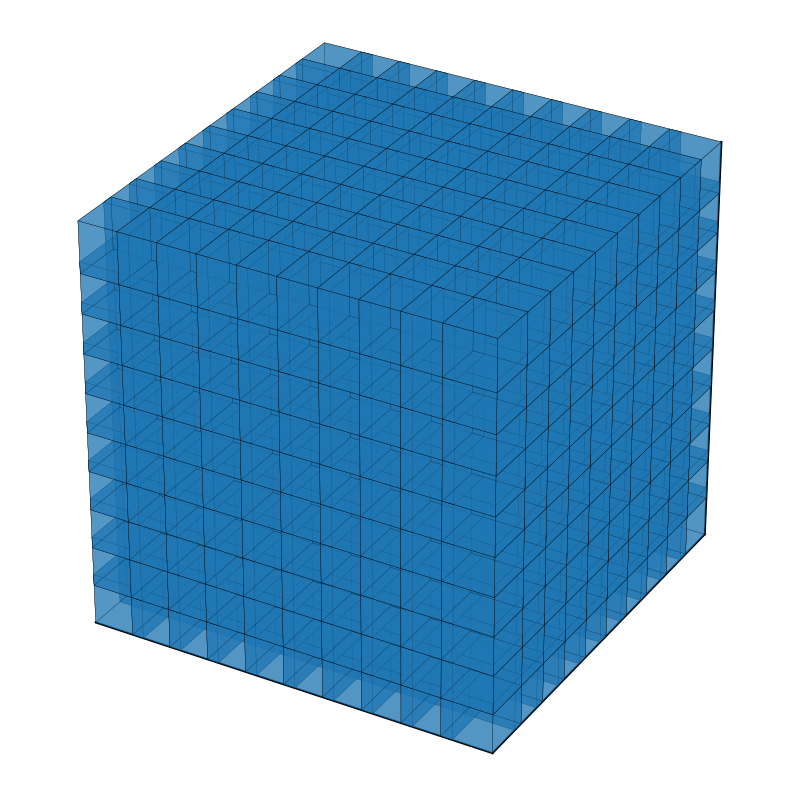

In [7]:
box_length = galaxy.gas["Coordinates"][:, 0].max() - galaxy.gas["Coordinates"][:, 0].min()

min_corner = galaxy.gas["Coordinates"].min(axis=0)
max_corner = galaxy.gas["Coordinates"].max(axis=0)
N = 10
cutout_size = box_length/2**3
spacing = (max_corner - min_corner - cutout_size) / (N - 1)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for i in range(N):
    for j in range(N):
        for k in range(N):
            cutout_min = min_corner + np.array([i, j, k]) * spacing
            cutout_max = cutout_min + cutout_size
            (xmin, ymin, zmin), (xmax, ymax, zmax) = (cutout_min, cutout_max)
            # Define the corners of the box
            verts = np.array([
                [xmin, ymin, zmin], [xmax, ymin, zmin],
                [xmax, ymax, zmin], [xmin, ymax, zmin],
                [xmin, ymin, zmax], [xmax, ymin, zmax],
                [xmax, ymax, zmax], [xmin, ymax, zmax]
            ])
            # Faces as lists of vertex indices
            faces = [
                [verts[i] for i in [0,1,2,3]],
                [verts[i] for i in [4,5,6,7]],
                [verts[i] for i in [0,1,5,4]],
                [verts[i] for i in [2,3,7,6]],
                [verts[i] for i in [1,2,6,5]],
                [verts[i] for i in [4,7,3,0]],
            ]

            poly = Poly3DCollection(faces, edgecolor='k', linewidths=0.2, alpha=0.5)
            ax.add_collection3d(poly)

ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_zlabel('')

ax.set_xlim(galaxy.gas["Coordinates"][:, 0].min(), galaxy.gas["Coordinates"][:, 0].max())
ax.set_ylim(galaxy.gas["Coordinates"][:, 1].min(), galaxy.gas["Coordinates"][:, 1].max())
ax.set_zlim(galaxy.gas["Coordinates"][:, 2].min(), galaxy.gas["Coordinates"][:, 2].max())
ax.set_box_aspect([1, 1, 1])

plt.tight_layout()
plt.show()
fig.savefig("cutouts.png")

In [4]:
box_length = galaxy.gas["Coordinates"][:, 0].max() - galaxy.gas["Coordinates"][:, 0].min()

min_corner = galaxy.gas["Coordinates"].min(axis=0)
max_corner = galaxy.gas["Coordinates"].max(axis=0)
N = 10
cutout_size = box_length/2**3
spacing = (max_corner - min_corner - cutout_size) / (N - 1)

result = np.zeros((N, N, N, 6))

for i, j, k in tqdm(np.ndindex(N, N, N), total=N**3, desc="Processing cutouts"):
    cutout_min = min_corner + np.array([i, j, k]) * spacing
    cutout_max = cutout_min + cutout_size
    in_box = (
        (galaxy.gas["Coordinates"][:, 0] >= cutout_min[0]) & (galaxy.gas["Coordinates"][:, 0] < cutout_max[0]) &
        (galaxy.gas["Coordinates"][:, 1] >= cutout_min[1]) & (galaxy.gas["Coordinates"][:, 1] < cutout_max[1]) &
        (galaxy.gas["Coordinates"][:, 2] >= cutout_min[2]) & (galaxy.gas["Coordinates"][:, 2] < cutout_max[2])
    )
    b1, rms_mach, dens_var, mean_dens, avg_soundspeed = nicegalaxy.compressive_ratio_measurment1_1(galaxy.gas["Coordinates"][in_box], 
                                                                                                    galaxy.gas["Velocities"][in_box],
                                                                                                    galaxy.gas["Density"][in_box], 
                                                                                                    galaxy.gas["InternalEnergy"][in_box], 
                                                                                                    galaxy.gas["Masses"][in_box], bounds=(cutout_min, cutout_max))
    b2 = nicegalaxy.compressive_ratio_measurment2(galaxy.gas["Coordinates"][in_box], 
                                                    galaxy.gas["Velocities"][in_box], 
                                                    galaxy.gas["Density"][in_box], 
                                                    galaxy.gas["Masses"][in_box], bounds=(cutout_min, cutout_max))
    result[i, j, k][0] = b1
    result[i, j, k][1] = b2
    result[i, j, k][2] = rms_mach
    result[i, j, k][3] = mean_dens
    result[i, j, k][4] = dens_var
    result[i, j, k][5] = avg_soundspeed

Processing cutouts: 100%|██████████| 1000/1000 [06:58<00:00,  2.39it/s]


In [5]:
result[5, 5, 5]

array([9.27914810e+00, 3.21600456e-01, 2.81154037e+00, 7.20766320e-06,
       1.88038553e-04, 1.11837760e-02])

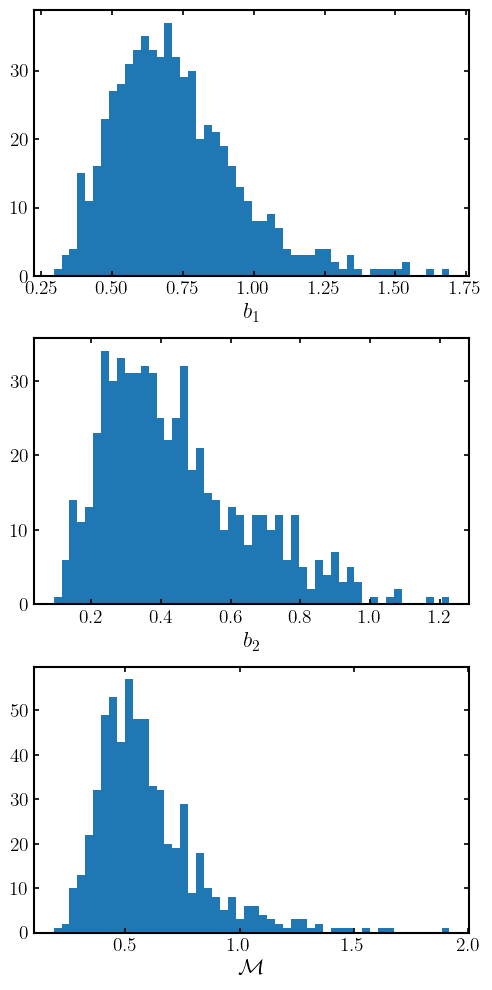

In [6]:
fig, axs = plt.subplots(3, 1, figsize=(5, 10))

axs[0].hist(result[:, :, :, 0][result[:, :, :, 5] > 0.3], bins=50)
axs[0].set_xlabel(r"$b_1$")
axs[1].hist(result[:, :, :, 1][result[:, :, :, 5] > 0.3], bins=50)
axs[1].set_xlabel(r"$b_2$")
axs[2].hist(result[:, :, :, 2][result[:, :, :, 5] > 0.3], bins=50)
axs[2].set_xlabel(r"$\mathcal{M}$")
fig.tight_layout()
fig.savefig("b_value_statistics.pdf")

In [ ]:
result[:, :, :, 5][result[:, :, :, 5] > 0.3].shape

(610,)

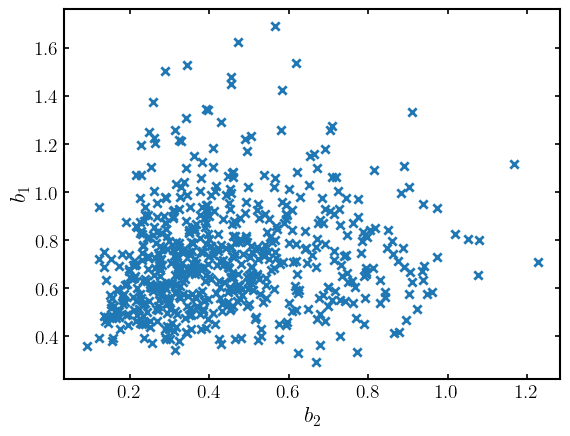

In [9]:
fig, ax = plt.subplots()

ax.scatter(result[:, :, :, 1][result[:, :, :, 5] > 0.3], result[:, :, :, 0][result[:, :, :, 5] > 0.3], marker="x")
ax.set_xlabel(r"$b_2$")
ax.set_ylabel(r"$b_1$")
fig.savefig("forcing_param_correlation.pdf")

Processing cutouts:   0%|          | 0/1000 [00:08<?, ?it/s]


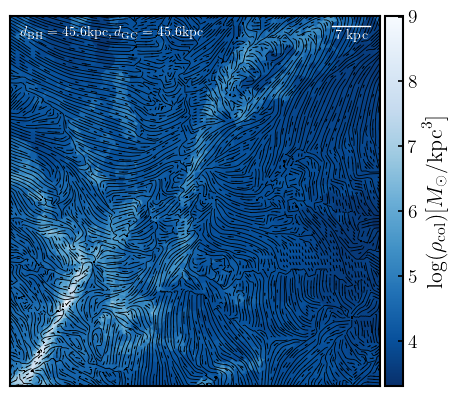

In [58]:
box_length = galaxy.gas["Coordinates"][:, 0].max() - galaxy.gas["Coordinates"][:, 0].min()

min_corner = galaxy.gas["Coordinates"].min(axis=0)
max_corner = galaxy.gas["Coordinates"].max(axis=0)
N = 10
cutout_size = box_length/2**3
spacing = (max_corner - min_corner - cutout_size) / (N - 1)

result = np.zeros((N, N, N, 6))

for i, j, k in tqdm(np.ndindex(N, N, N), total=N**3, desc="Processing cutouts"):
    cutout_min = min_corner + np.array([4, 5, 5]) * spacing
    cutout_max = cutout_min + cutout_size
    in_box = (
        (galaxy.gas["Coordinates"][:, 0] >= cutout_min[0]) & (galaxy.gas["Coordinates"][:, 0] < cutout_max[0]) &
        (galaxy.gas["Coordinates"][:, 1] >= cutout_min[1]) & (galaxy.gas["Coordinates"][:, 1] < cutout_max[1]) &
        (galaxy.gas["Coordinates"][:, 2] >= cutout_min[2]) & (galaxy.gas["Coordinates"][:, 2] < cutout_max[2])
    )
    fig, ax = plt.subplots()
    grid_size = 500
    grid = (range(grid_size), range(grid_size), range(100, 101))
    structured_gas = nicegalaxy.map_unstructured_to_structured_slice_optimized(galaxy.gas["Coordinates"][in_box], galaxy.gas["Density"][in_box], grid_size=grid_size, grid=grid)
    structured_bfield = nicegalaxy.map_unstructured_to_structured_slice_optimized(galaxy.gas["Coordinates"][in_box], galaxy.gas["MagneticField"][in_box], grid_size=grid_size, grid=grid)
    x = np.linspace(0, grid_size, grid_size)
    y = np.linspace(0, grid_size, grid_size)
    X, Y = np.meshgrid(x, y)
    scalebar_length = round(cutout_size/10)
    scalebar_pixels = scalebar_length/cutout_size * structured_gas.shape[0]
    center = 0.5 * (cutout_max + cutout_min)
    closest_bh_dist = np.min(np.linalg.norm(galaxy.bhs["Coordinates"] - center, axis=-1))
    gc_dist = np.linalg.norm(np.linalg.norm(galaxy.bhs["Coordinates"][0] - center))
    im = ax.imshow(np.log10(structured_gas) + 10, cmap="Blues_r", interpolation=None)
    stream = ax.streamplot(
        X, Y, structured_bfield[:, :, 0], structured_bfield[:, :, 1],
        color='black',      # contrast color against background
        linewidth=0.6,
        density=4.0,
        arrowstyle='-',     # no arrows
        integration_direction='both',
        minlength=0.001,
    )
    ax.plot([structured_gas.shape[0]*(1 - 1/40) - scalebar_pixels, structured_gas.shape[0]*(1 - 1/40)], [structured_gas.shape[0]/40, structured_gas.shape[0]/40], color='white', linewidth=1)
    ax.text(structured_gas.shape[0]*(1 - 1/40) - scalebar_pixels/2, structured_gas.shape[0]/30, f"{scalebar_length} kpc", ha="center", va="top", color="white")
    ax.text(structured_gas.shape[0]*1/40, structured_gas.shape[0]*1/40, rf"$d_{{\mathrm{{BH}}}} = {closest_bh_dist:.1f} \mathrm{{kpc}}, d_{{\mathrm{{GC}}}} = {gc_dist:.1f} \mathrm{{kpc}}$", va="top", color="white")
    ax.set_xticks([])
    ax.set_yticks([])
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = plt.colorbar(im, cax=cax, label=r"$\mathrm{log}(\rho_{\mathrm{col}}) [M_{\odot}/\mathrm{kpc}^3]$")
    fig.savefig(f"cutout-images/cutout_magnetic.png", bbox_inches='tight', dpi=500)
    break

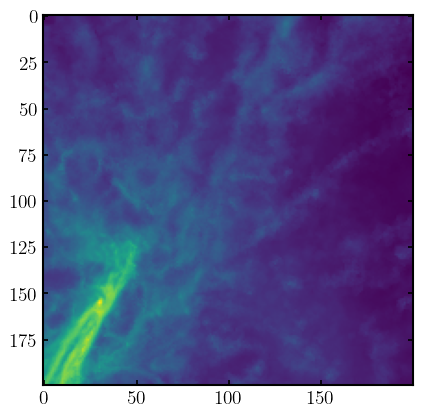

In [ ]:
fig, ax = plt.subplots()
ax.imshow(np.log10(structured_gas))

In [4]:
whole = nicegalaxy.structured_column(galaxy.gas["Coordinates"], galaxy.gas["Density"], grid_size=500)

Slicing: 100%|██████████| 500/500 [00:59<00:00,  8.38it/s]


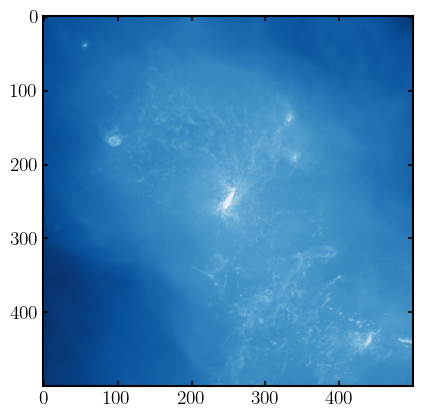

In [ ]:
plt.imshow(np.log10(whole), cmap="Blues_r")
plt.show()

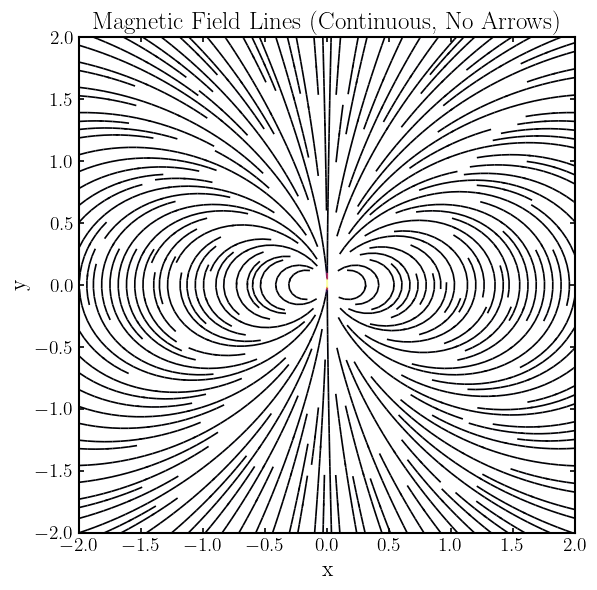

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# Grid
x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x, y)

# Magnetic dipole field in 2D (z = 0)
r = np.sqrt(X**2 + Y**2) + 1e-9
Bx = (3 * X * Y) / r**5
By = (2 * Y**2 - X**2) / r**5

# Normalize (optional)
B_mag = np.sqrt(Bx**2 + By**2)
Bx /= B_mag
By /= B_mag

# Streamplot without arrows (arrowstyle='-' hides them)
fig, ax = plt.subplots(figsize=(6, 6))
stream = ax.streamplot(
    X, Y, Bx, By,
    color=B_mag,
    cmap='inferno',
    linewidth=1.2,
    arrowstyle='-',  # <--- disables arrows
    density=2.0      # Increase for more continuous lines
)

ax.set_title("Magnetic Field Lines (Continuous, No Arrows)")
ax.set_aspect('equal')
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()
